In [1]:
import pandas as pd
from sklearn.cluster import KMeans

df = pd.read_excel('data.xlsx')
print(df.head(5))

     Customer   LONGITUD   LATITUDE
0  1307044192  26.910482  43.274370
1  1307145057  26.906359  43.278991
2  1310001992  26.233979  43.347380
3  1305139450  24.697928  42.004410
4  1306138541  26.574830  43.240130


In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# -----------------------------
# 1. CLEAN DATA
# -----------------------------
df.columns = df.columns.str.strip()
df = df.dropna(subset=['LONGITUD', 'LATITUDE']).copy()

X = df[['LONGITUD', 'LATITUDE']].values

# -----------------------------
# 2. GEOGRAPHIC KMEANS
# -----------------------------
k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=20
)

df['Cluster'] = kmeans.fit_predict(X) + 1

# -----------------------------
# 3. SORT CLUSTERS (за по-ясни територии)
# -----------------------------
centroids = kmeans.cluster_centers_

# сортираме по географски център (latitude)
order = np.argsort(centroids[:, 1])

mapping = {old: new+1 for new, old in enumerate(order)}

df['Cluster'] = df['Cluster'].map(lambda x: mapping[x-1])

# -----------------------------
# 4. SAVE
# -----------------------------
with pd.ExcelWriter('clustered.xlsx') as writer:
    df.to_excel(writer, sheet_name='Clusters', index=False)

print("Готово ✔ географски центрирани клъстери")
print(df['Cluster'].value_counts().sort_index())

Готово ✔ географски центрирани клъстери
Cluster
1    4723
2    6433
3    3520
4    3322
Name: count, dtype: int64


In [3]:
test = pd.read_excel('clustered.xlsx')
print(test.head(5))

     Customer   LONGITUD   LATITUDE  Cluster
0  1307044192  26.910482  43.274370        4
1  1307145057  26.906359  43.278991        4
2  1310001992  26.233979  43.347380        3
3  1305139450  24.697928  42.004410        1
4  1306138541  26.574830  43.240130        3


In [4]:
df['Cluster'].value_counts().sort_index()

Cluster
1    4723
2    6433
3    3520
4    3322
Name: count, dtype: int64

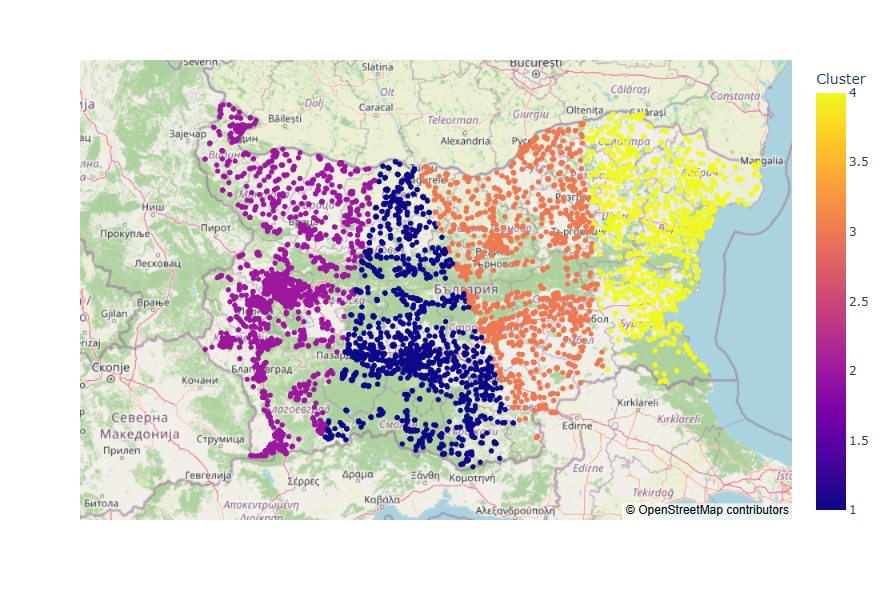

In [5]:
import plotly.express as px

fig = px.scatter_map(
    df,
    lat="LATITUDE",
    lon="LONGITUD",
    color="Cluster",
    hover_name="Customer",
    zoom=6,
    height=600
)

fig.update_layout(map_style="open-street-map")
fig.show()

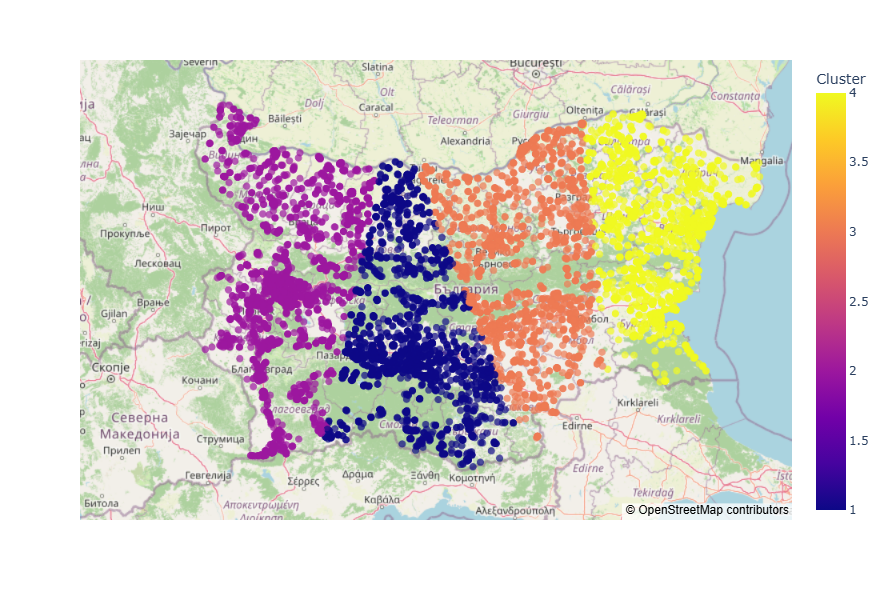

In [6]:
fig.update_traces(marker=dict(size=8, opacity=0.7))
fig.update_layout(map_style="open-street-map")

fig.show()


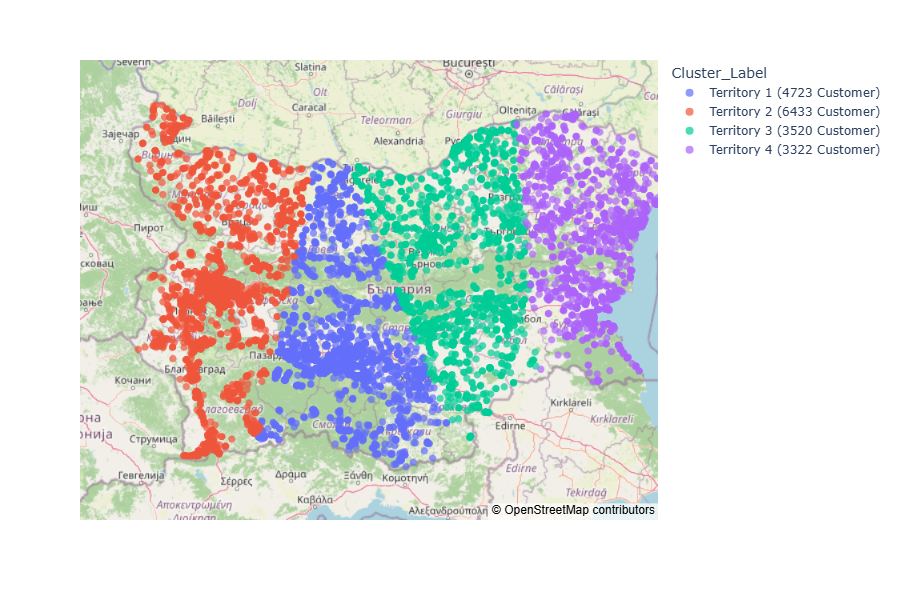

In [7]:
df = df.sort_values('Cluster')

counts = df['Cluster'].value_counts().sort_index()

df['Cluster_Label'] = df['Cluster'].map(
    lambda x: f"Territory {x} ({counts[x]} Customer)"
)

fig = px.scatter_map(
    df,
    lat="LATITUDE",
    lon="LONGITUD",
    color="Cluster_Label",
    hover_name="Customer",
    zoom=6,
    height=600
)

fig.update_traces(marker=dict(size=8, opacity=0.7))
fig.update_layout(map_style="open-street-map")

fig.show()

In [12]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

# -----------------------------
# 1. CLEAN DATA
# -----------------------------
df.columns = df.columns.str.strip()
df = df.dropna(subset=['LONGITUD', 'LATITUDE']).copy()
df = df.reset_index(drop=True)

X = df[['LONGITUD', 'LATITUDE']].values

# -----------------------------
# 2. INITIAL KMEANS (GEOGRAPHIC SEED)
# -----------------------------
k = 80
kmeans = KMeans(n_clusters=k, random_state=42, n_init=30)
df['Cluster'] = kmeans.fit_predict(X)

centroids = kmeans.cluster_centers_

# -----------------------------
# 3. PRO GIS OPTIMIZATION LOOP
# -----------------------------
n = len(df)
target = n // k

for iteration in range(5):  # повече итерации = по-добро

    distances = cdist(X, centroids)
    sizes = df['Cluster'].value_counts().to_dict()

    changed = 0

    # сортираме по "нестабилни" точки (най-далечни от център)
    instability = np.min(distances, axis=1)
    order = np.argsort(-instability)

    for i in order:

        current = df.at[i, 'Cluster']

        # ако клъстерът е пренаселен
        if sizes.get(current, 0) > target:

            # намираме най-близкия допустим клъстер
            best = np.argsort(distances[i])

            for c in best:
                if sizes.get(c, 0) < target:

                    df.at[i, 'Cluster'] = c
                    sizes[current] -= 1
                    sizes[c] = sizes.get(c, 0) + 1
                    changed += 1
                    break

    # -----------------------------
    # 4. SMOOTH CENTROIDS (GIS STYLE)
    # -----------------------------
    centroids = df.groupby('Cluster')[['LONGITUD', 'LATITUDE']].mean().values

    if changed == 0:
        break

# -----------------------------
# 5. FINAL CLEANUP
# -----------------------------
df['Cluster'] = df['Cluster'] + 1

# -----------------------------
# 6. EXPORT (GIS READY)
# -----------------------------
with pd.ExcelWriter('GIS_territories.xlsx') as writer:
    df.to_excel(writer, sheet_name='Points', index=False)

# centroids layer (GIS layer)
centroids_df = df.groupby('Cluster')[['LONGITUD', 'LATITUDE']].mean().reset_index()
centroids_df.to_excel('GIS_centroids.xlsx', index=False)

print("✔ PRO GIS TERRITORIES DONE")
print(df['Cluster'].value_counts().sort_index())

✔ PRO GIS TERRITORIES DONE
Cluster
1     224
2     302
3     224
4     224
5     224
     ... 
76    224
77    224
78    224
79    224
80    224
Name: count, Length: 80, dtype: int64


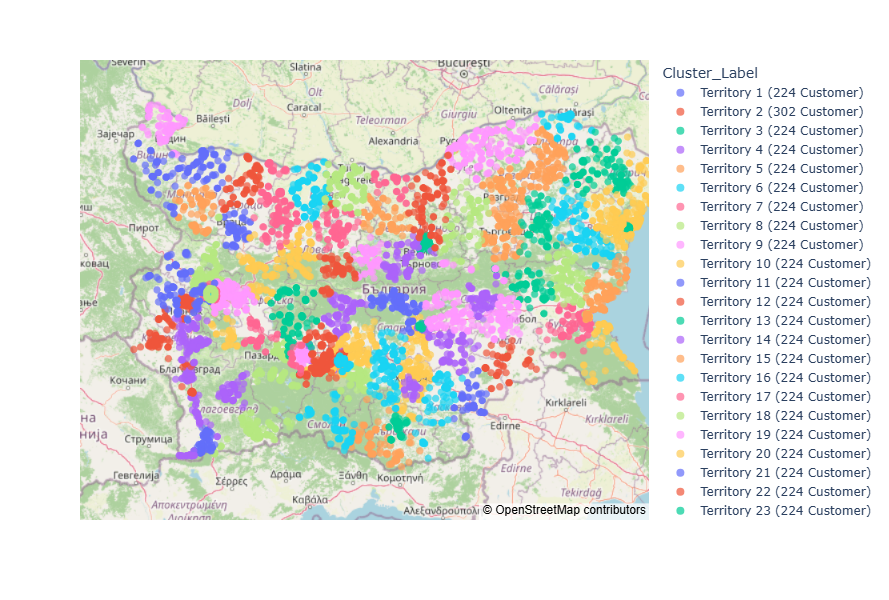

In [13]:
df = df.sort_values('Cluster')

counts = df['Cluster'].value_counts().sort_index()

df['Cluster_Label'] = df['Cluster'].map(
    lambda x: f"Territory {x} ({counts[x]} Customer)"
)

fig = px.scatter_map(
    df,
    lat="LATITUDE",
    lon="LONGITUD",
    color="Cluster_Label",
    hover_name="Customer",
    zoom=6,
    height=600
)

fig.update_traces(marker=dict(size=8, opacity=0.7))
fig.update_layout(map_style="open-street-map")

fig.show()